Step 1: Imports & Setup

In [8]:
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
# ── REDEFINE ALL VARIABLES ───────────────────────────────────
from pathlib import Path

IMG_HEIGHT   = 128
IMG_WIDTH    = 128
BATCH_SIZE   = 32
NUM_CLASSES  = 5

dataset_root      = Path("/content/drive/MyDrive/AI & ML/AI_Assesment/Flower Classification")
train_dir         = dataset_root / "Train"
test_dir          = dataset_root / "Test"
augmented_train_dir = dataset_root / "Augmented_Train"

print("All variables defined ✓")
print("Train dir exists       :", train_dir.exists())
print("Augmented dir exists   :", augmented_train_dir.exists())

All variables defined ✓
Train dir exists       : True
Augmented dir exists   : False


In [11]:
from google.colab import drive
drive.mount('/content/drive')

dataset_root = Path("/content/drive/MyDrive/AI & ML/AI_Assesment/Flower Classification")
train_dir = dataset_root / "Train"
test_dir  = dataset_root / "Test"

print("Train dir exists:", train_dir.exists())
print("Test dir exists: ", test_dir.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train dir exists: True
Test dir exists:  True


Step 2 — Data Analysis & Visualization (Section 2.5.1)

In [12]:
# Count images per class in training directory
train_class_counts = {}
train_total = 0

for cls_path in sorted(train_dir.iterdir()):
    if cls_path.is_dir():
        imgs = [f for f in cls_path.glob("*.*")
                if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
        train_class_counts[cls_path.name] = len(imgs)
        train_total += len(imgs)

# Count test images
test_total = len([f for f in test_dir.iterdir()
                  if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png']])

print("=" * 45)
print("        DATASET SUMMARY")
print("=" * 45)
print(f"Total Training Images : {train_total}")
print(f"Total Test Images     : {test_total}")
print(f"Total Images Overall  : {train_total + test_total}")
print(f"Number of Classes     : {len(train_class_counts)}")
print("=" * 45)
print("\nClass Distribution (Training):")
print("-" * 45)
for cls, count in train_class_counts.items():
    bar = "█" * (count // 50)
    print(f"  {cls:<12}: {count:>4} images ({count/train_total*100:.1f}%)  {bar}")
print("-" * 45)

        DATASET SUMMARY
Total Training Images : 4312
Total Test Images     : 5
Total Images Overall  : 4317
Number of Classes     : 5

Class Distribution (Training):
---------------------------------------------
  daisy       :  763 images (17.7%)  ███████████████
  dandelion   : 1051 images (24.4%)  █████████████████████
  rose        :  783 images (18.2%)  ███████████████
  sunflower   :  732 images (17.0%)  ██████████████
  tulip       :  983 images (22.8%)  ███████████████████
---------------------------------------------


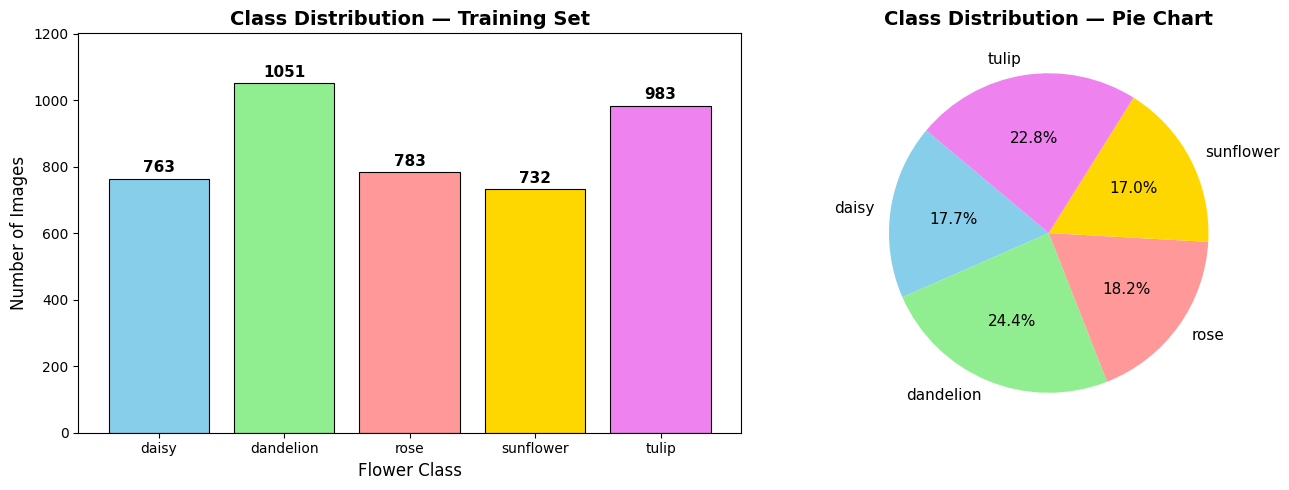

Chart saved as class_distribution.png


In [13]:
#Bar chart of class distribution
classes = list(train_class_counts.keys())
counts  = list(train_class_counts.values())
colors  = ['#87CEEB', '#90EE90', '#FF9999', '#FFD700', '#EE82EE']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(classes, counts, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution — Training Set', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Flower Class', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_ylim(0, max(counts) + 150)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(count), ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=classes, colors=colors, autopct='%1.1f%%',
            startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Class Distribution — Pie Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as class_distribution.png")

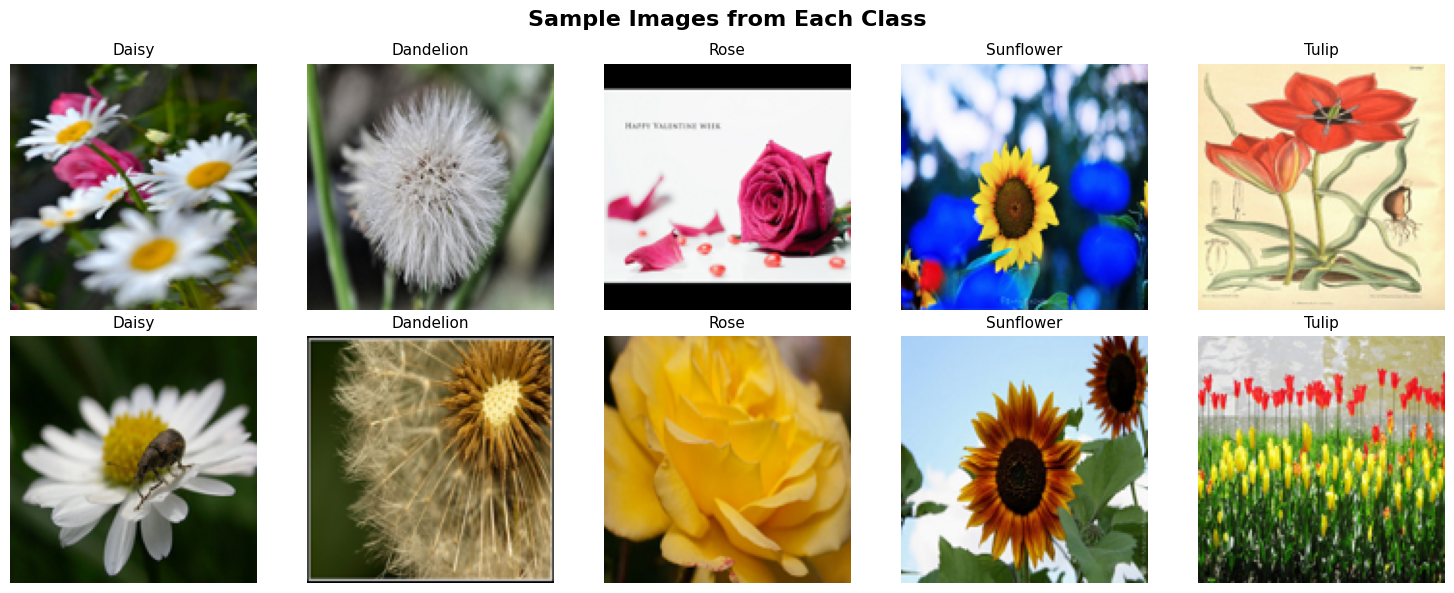

Chart saved as sample_images.png


In [14]:
#Sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold')

for col, (cls_name, _) in enumerate(train_class_counts.items()):
    cls_path = train_dir / cls_name
    img_files = [f for f in cls_path.glob("*.*")
                 if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]

    for row in range(2):
        img = Image.open(random.choice(img_files)).resize((128, 128))
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls_name.capitalize(), fontsize=11)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as sample_images.png")

In [15]:
#Scan and remove corrupted images
from PIL import UnidentifiedImageError

print("Scanning for corrupted images...\n")

corrupted = []
total_scanned = 0

for cls_path in sorted(train_dir.iterdir()):
    if not cls_path.is_dir():
        continue
    cls_corrupted = 0
    for img_path in cls_path.glob("*.*"):
        if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
            continue
        total_scanned += 1
        try:
            img = Image.open(img_path)
            img.verify()  # checks if file is broken
        except (UnidentifiedImageError, Exception):
            corrupted.append(img_path)
            cls_corrupted += 1
    print(f"  {cls_path.name:<12}: scanned | {cls_corrupted} corrupted")

print(f"\nTotal scanned  : {total_scanned}")
print(f"Total corrupted: {len(corrupted)}")

if corrupted:
    print("\nCorrupted files found:")
    for f in corrupted:
        print(f"  {f}")
else:
    print("\nNo corrupted images found. Dataset is clean ✓")

Scanning for corrupted images...

  daisy       : scanned | 7 corrupted
  dandelion   : scanned | 7 corrupted
  rose        : scanned | 7 corrupted
  sunflower   : scanned | 7 corrupted
  tulip       : scanned | 7 corrupted

Total scanned  : 4312
Total corrupted: 35

Corrupted files found:
  /content/drive/MyDrive/AI & ML/AI_Assesment/Flower Classification/Train/daisy/34532930772_5cc5fc600d_n.jpg
  /content/drive/MyDrive/AI & ML/AI_Assesment/Flower Classification/Train/daisy/33884228533_91b75ff4d4_n.jpg
  /content/drive/MyDrive/AI & ML/AI_Assesment/Flower Classification/Train/daisy/2536529152_33ef3ee078_n.jpg
  /content/drive/MyDrive/AI & ML/AI_Assesment/Flower Classification/Train/daisy/3475870145_685a19116d.jpg
  /content/drive/MyDrive/AI & ML/AI_Assesment/Flower Classification/Train/daisy/4563059851_45a9d21a75.jpg
  /content/drive/MyDrive/AI & ML/AI_Assesment/Flower Classification/Train/daisy/33880234094_2541c9c83d_n.jpg
  /content/drive/MyDrive/AI & ML/AI_Assesment/Flower Classific

In [16]:
#Remove corrupted images if any found
if corrupted:
    print(f"Removing {len(corrupted)} corrupted images...\n")
    for f in corrupted:
        f.unlink()  # deletes the file
        print(f"  Deleted: {f.name}")

    # Recount after cleaning
    train_class_counts = {}
    train_total = 0
    for cls_path in sorted(train_dir.iterdir()):
        if cls_path.is_dir():
            imgs = [f for f in cls_path.glob("*.*")
                    if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
            train_class_counts[cls_path.name] = len(imgs)
            train_total += len(imgs)

    print("\nUpdated class counts after cleaning:")
    for cls, count in train_class_counts.items():
        print(f"  {cls:<12}: {count} images")
    print(f"\nTotal clean images: {train_total}")

else:
    print("No corrupted images to remove. Proceeding with original counts.")
    print(f"Total clean images: {train_total}")

Removing 35 corrupted images...

  Deleted: 34532930772_5cc5fc600d_n.jpg
  Deleted: 33884228533_91b75ff4d4_n.jpg
  Deleted: 2536529152_33ef3ee078_n.jpg
  Deleted: 3475870145_685a19116d.jpg
  Deleted: 4563059851_45a9d21a75.jpg
  Deleted: 33880234094_2541c9c83d_n.jpg
  Deleted: 2908212142_5437fa67ff_n.jpg
  Deleted: 10919961_0af657c4e8.jpg
  Deleted: 34729107795_c746845e17_n.jpg
  Deleted: 7015947703_11b30c20c9_n.jpg
  Deleted: 468749497_951c571eff_n.jpg
  Deleted: 34323645656_afd53a9996_n.jpg
  Deleted: 17075803866_aeeded2637.jpg
  Deleted: 2995221296_a6ddaccc39.jpg
  Deleted: 5206847130_ee4bf0e4de_n.jpg
  Deleted: 16001846141_393fdb887e_n.jpg
  Deleted: 4279990882_031482f8b6_n.jpg
  Deleted: 18490508225_0fc630e963_n.jpg
  Deleted: 568715474_bdb64ccc32.jpg
  Deleted: 7471890786_aaff777641_n.jpg
  Deleted: 3407482427_49d5c75291_m.jpg
  Deleted: 20407896403_a50fef58ac_n.jpg
  Deleted: 3894586562_5dbbdc4354_n.jpg
  Deleted: 16616096711_12375a0260_n.jpg
  Deleted: 20812318934_82f10c45a1_n.j


Augmentation




In [17]:
#Augment & balance classes to 1500 each
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augmented_train_dir = dataset_root / "Augmented_Train"
target_per_class = 1500

# Setup augmentation generator
aug_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Check if already done
already_done = False
if augmented_train_dir.exists():
    counts_check = {}
    for cls_path in augmented_train_dir.iterdir():
        if cls_path.is_dir():
            n = len([f for f in cls_path.glob("*.*")
                     if f.suffix.lower() in ['.jpg','.jpeg','.png']])
            counts_check[cls_path.name] = n
    if len(counts_check) == NUM_CLASSES and all(v >= target_per_class for v in counts_check.values()):
        already_done = True
        print("Augmented dataset already exists and is balanced. Skipping.")
        for cls, cnt in counts_check.items():
            print(f"  {cls:<12}: {cnt} images")

if not already_done:
    if augmented_train_dir.exists():
        shutil.rmtree(augmented_train_dir)
    augmented_train_dir.mkdir(parents=True)
    print("Starting augmentation...\n")

    for cls_name, original_count in train_class_counts.items():
        cls_src  = train_dir / cls_name
        cls_dest = augmented_train_dir / cls_name
        cls_dest.mkdir()

        # Get all original images
        orig_imgs = [f for f in cls_src.glob("*.*")
                     if f.suffix.lower() in ['.jpg','.jpeg','.png']]

        # Copy originals first
        for img_path in orig_imgs:
            shutil.copy(img_path, cls_dest / img_path.name)

        # Generate extra images to reach target
        needed = target_per_class - original_count
        generated = 0

        for i in range(needed):
            src_path = random.choice(orig_imgs)
            img = keras.utils.load_img(src_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
            x   = keras.utils.img_to_array(img).astype('float32')
            x_aug = aug_datagen.random_transform(x)
            aug_img = Image.fromarray(np.clip(x_aug, 0, 255).astype('uint8'))
            aug_img.save(cls_dest / f"aug_{cls_name}_{i:04d}.jpeg")
            generated += 1

        total = original_count + generated
        print(f"  {cls_name:<12}: {original_count} original + {generated} augmented = {total} total")

    print("\nAugmentation complete!")

Starting augmentation...

  daisy       : 756 original + 744 augmented = 1500 total
  dandelion   : 1044 original + 456 augmented = 1500 total
  rose        : 776 original + 724 augmented = 1500 total
  sunflower   : 725 original + 775 augmented = 1500 total
  tulip       : 976 original + 524 augmented = 1500 total

Augmentation complete!


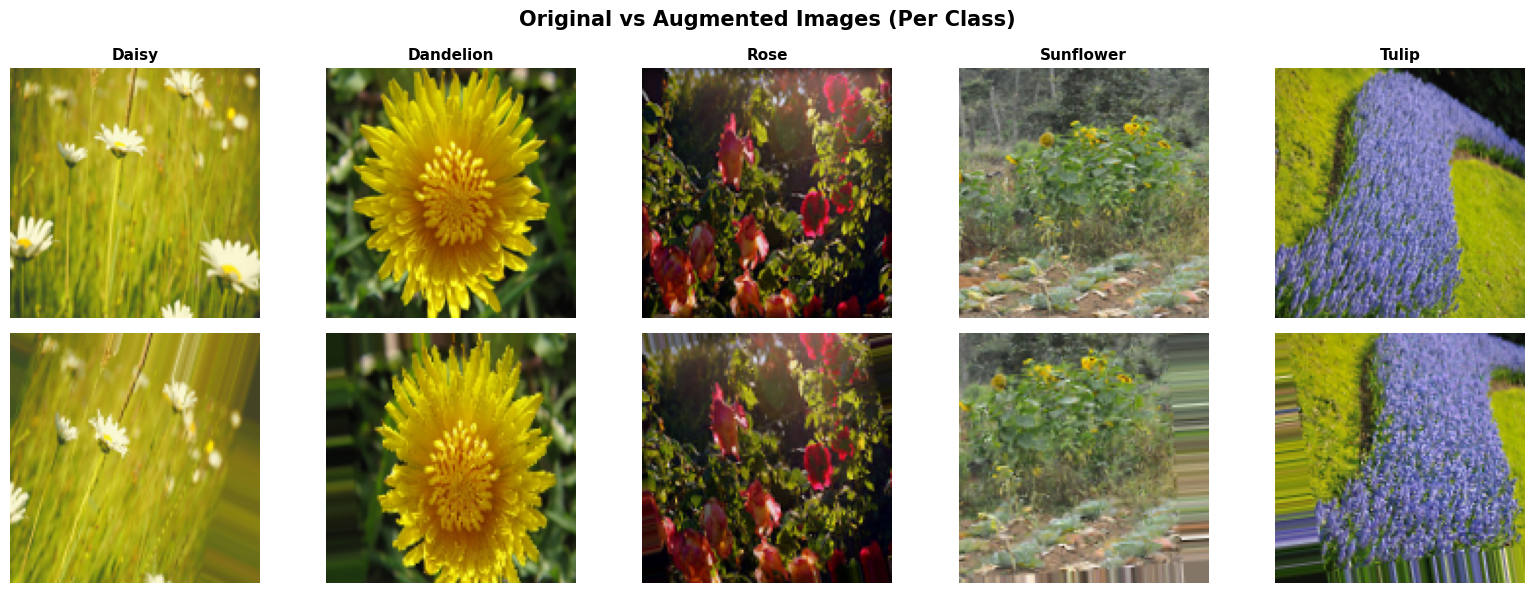

Saved as augmentation_comparison.png


In [18]:
#Visualize original vs augmented
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(16, 6))
fig.suptitle('Original vs Augmented Images (Per Class)', fontsize=15, fontweight='bold')

aug_demo = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.2,
    height_shift_range=0.2, shear_range=0.2,
    zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
)

for col, cls_name in enumerate(sorted(train_class_counts.keys())):
    cls_path  = train_dir / cls_name
    img_files = [f for f in cls_path.glob("*.*")
                 if f.suffix.lower() in ['.jpg','.jpeg','.png']]
    chosen    = random.choice(img_files)

    # Original
    orig = Image.open(chosen).resize((IMG_HEIGHT, IMG_WIDTH))
    axes[0, col].imshow(orig)
    axes[0, col].set_title(cls_name.capitalize(), fontsize=11, fontweight='bold')
    axes[0, col].set_ylabel('Original' if col == 0 else '', fontsize=10)
    axes[0, col].axis('off')

    # Augmented
    x     = keras.utils.img_to_array(
                keras.utils.load_img(chosen, target_size=(IMG_HEIGHT, IMG_WIDTH))
            ).astype('float32')
    x_aug = aug_demo.random_transform(x)
    axes[1, col].imshow(np.clip(x_aug, 0, 255).astype('uint8'))
    axes[1, col].set_ylabel('Augmented' if col == 0 else '', fontsize=10)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as augmentation_comparison.png")

In [19]:
#Final Train/Val Generators
aug_datagen_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = aug_datagen_gen.flow_from_directory(
    augmented_train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    seed=42,
    shuffle=True
)

val_gen = aug_datagen_gen.flow_from_directory(
    augmented_train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    seed=42,
    shuffle=False
)

print("Class indices    :", train_gen.class_indices)
print(f"Training samples  : {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Training batches  : {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")

Found 6000 images belonging to 5 classes.
Found 1500 images belonging to 5 classes.
Class indices    : {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
Training samples  : 6000
Validation samples: 1500
Training batches  : 188
Validation batches: 47


2.5.2 Design, Train, and Evaluate a Baseline Model:

In [20]:
# ── BASELINE MODEL ──────────────────────────────────────────
baseline_model = keras.Sequential([
    keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Conv Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Conv Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Flatten
    layers.Flatten(),

    # FCN Layer 1
    layers.Dense(256, activation='relu'),

    # FCN Layer 2
    layers.Dense(128, activation='relu'),

    # FCN Layer 3
    layers.Dense(64, activation='relu'),

    # Output Layer
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="Baseline_CNN")

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,589 (32.51 MB)

 Trainable params: 8,523,589 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#Train the Baseline Model
import time

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/AI & ML/AI_Assesment/baseline_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train
print("Training Baseline Model...\n")
start_time = time.time()

baseline_history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

baseline_train_time = time.time() - start_time
print(f"\nTotal training time: {baseline_train_time/60:.2f} minutes")

Training Baseline Model...

Epoch 1/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.5972 - loss: 1.0070
Epoch 1: val_accuracy improved from None to 0.58467, saving model to /content/drive/MyDrive/AI & ML/AI_Assesment/baseline_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI & ML/AI_Assesment/baseline_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 40s 215ms/step - accuracy: 0.6083 - loss: 0.9794 - val_accuracy: 0.5847 - val_loss: 1.0065
Epoch 2/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.6943 - loss: 0.8131
Epoch 2: val_accuracy improved from 0.58467 to 0.68267, saving model to /content/drive/MyDrive/AI & ML/AI_Assesment/baseline_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI & ML/AI_Assesment/baseline_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 37s 192ms/step - accuracy: 0.6950 - loss: 0.8004 - val_accuracy: 0.6827 - val_loss: 0.8305
Epoch 3/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.7722 - loss: 0.6122
E

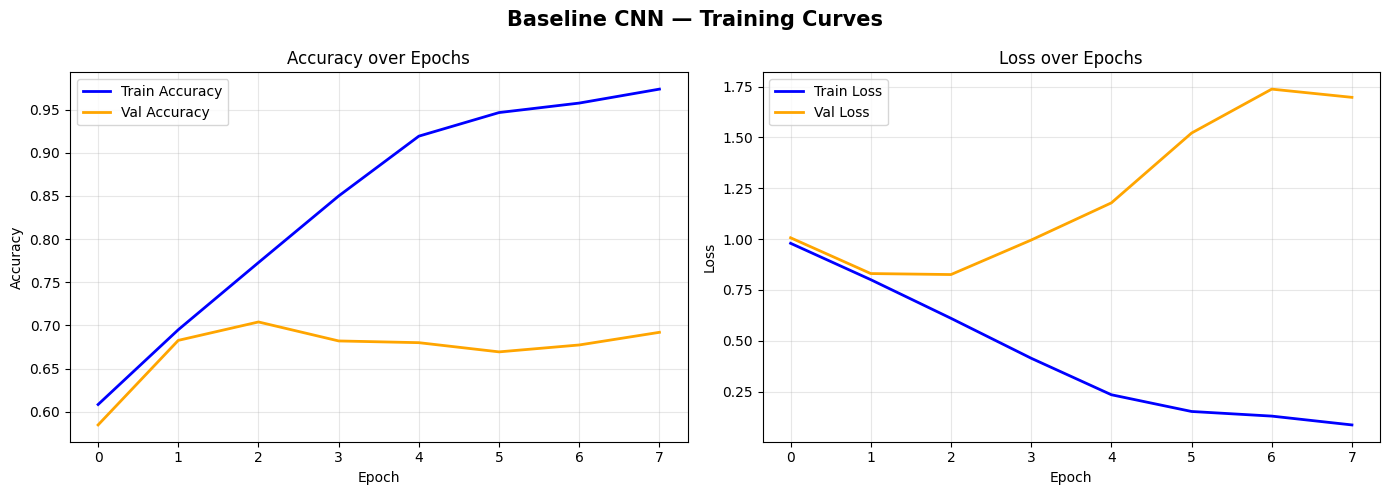

In [23]:
def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training Curves', fontsize=15, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='blue',   linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange', linewidth=2)
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='blue',   linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange', linewidth=2)
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curves(baseline_history, 'Baseline CNN')

In [24]:
#Evaluate Baseline Model
val_gen.reset()
y_pred_probs = baseline_model.predict(val_gen, verbose=1)
y_pred  = np.argmax(y_pred_probs, axis=1)
y_true  = val_gen.classes
class_names = list(train_gen.class_indices.keys())

print("=" * 55)
print("     BASELINE MODEL — EVALUATION REPORT")
print("=" * 55)
print(classification_report(y_true, y_pred, target_names=class_names))

val_loss, val_acc = baseline_model.evaluate(val_gen, verbose=0)
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Training Time       : {baseline_train_time/60:.2f} minutes")

47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step
     BASELINE MODEL — EVALUATION REPORT
              precision    recall  f1-score   support

       daisy       0.76      0.75      0.76       300
   dandelion       0.69      0.76      0.72       300
        rose       0.71      0.53      0.61       300
   sunflower       0.71      0.86      0.77       300
       tulip       0.65      0.61      0.63       300

    accuracy                           0.70      1500
   macro avg       0.70      0.70      0.70      1500
weighted avg       0.70      0.70      0.70      1500

Validation Accuracy : 70.40%
Validation Loss     : 0.8256
Training Time       : 4.86 minutes


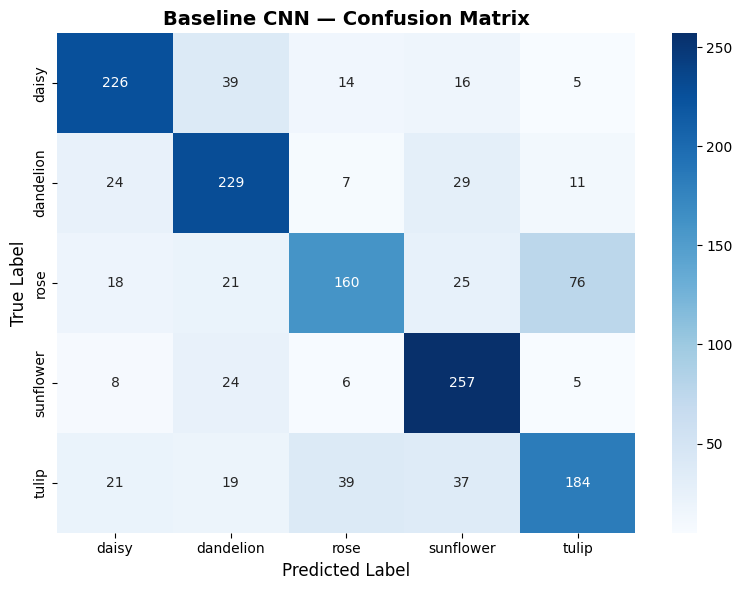

In [25]:
#Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Baseline CNN — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

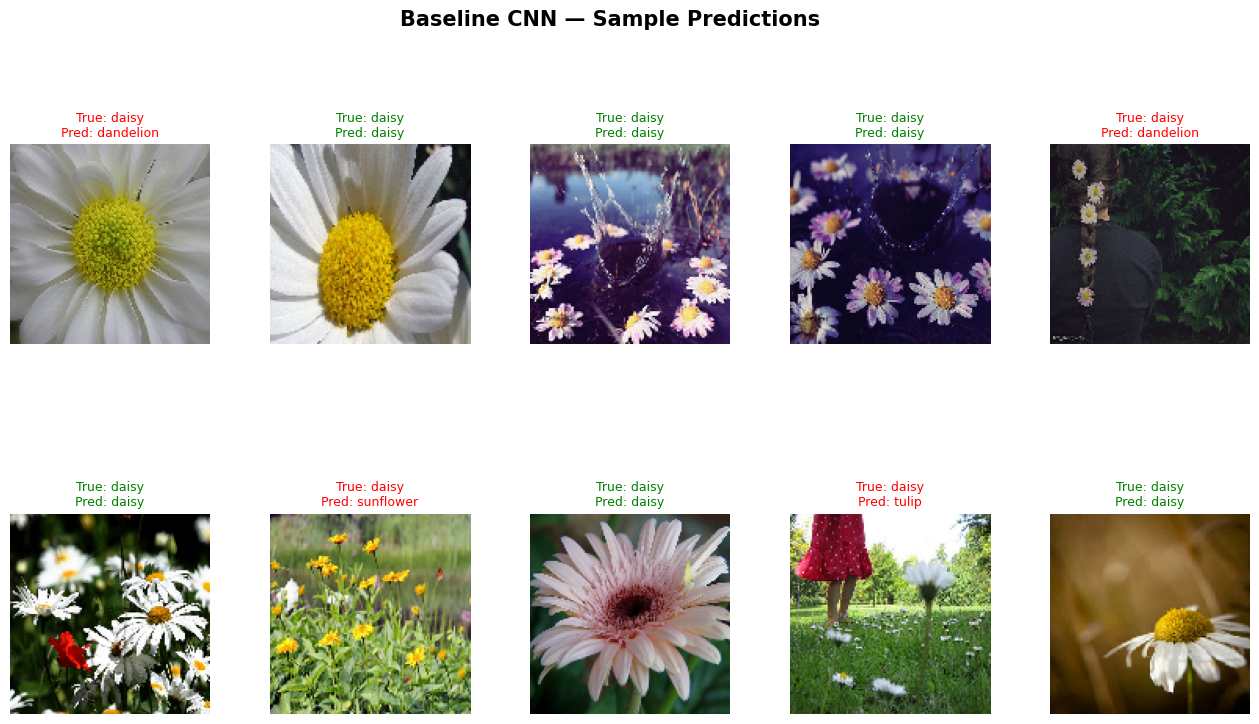

In [26]:
#Sample Predictions
val_gen.reset()
images, labels = next(val_gen)

fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle('Baseline CNN — Sample Predictions', fontsize=15, fontweight='bold', y=1.02)

for i, ax in enumerate(axes.flat):
    img  = images[i]
    true = class_names[int(labels[i])]
    pred = class_names[np.argmax(baseline_model.predict(img[np.newaxis,...], verbose=0))]
    color = 'green' if true == pred else 'red'
    ax.imshow(img)
    ax.set_title(f'True: {true}\nPred: {pred}', color=color, fontsize=9, pad=6)
    ax.axis('off')

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

2.5.3 Deeper Architecture with Regularization Layer:

In [27]:
# ── DEEPER MODEL ────────────────────────────────────────────
deeper_model = keras.Sequential([
    keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Conv Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv Block 5
    layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Global Average Pooling instead of Flatten
    layers.GlobalAveragePooling2D(),

    # FCN Layers
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # Output
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="Deeper_CNN")

deeper_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,788,901 (10.64 MB)

 Trainable params: 2,784,421 (10.62 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [28]:
# ── TRAIN DEEPER MODEL ──────────────────────────────────────
print("Training Deeper Model...\n")

early_stop_deep = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

checkpoint_deep = ModelCheckpoint(
    '/content/drive/MyDrive/AI & ML/AI_Assesment/deeper_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

start_time_deep = time.time()

deeper_history = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    callbacks=[early_stop_deep, checkpoint_deep],
    verbose=1
)

deeper_train_time = time.time() - start_time_deep
print(f"\nTotal training time: {deeper_train_time/60:.2f} minutes")

Training Deeper Model...

Epoch 1/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.3335 - loss: 1.9222
Epoch 1: val_accuracy improved from None to 0.20067, saving model to /content/drive/MyDrive/AI & ML/AI_Assesment/deeper_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI & ML/AI_Assesment/deeper_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 83s 298ms/step - accuracy: 0.3883 - loss: 1.6903 - val_accuracy: 0.2007 - val_loss: 3.5666
Epoch 2/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.4577 - loss: 1.3933
Epoch 2: val_accuracy improved from 0.20067 to 0.33400, saving model to /content/drive/MyDrive/AI & ML/AI_Assesment/deeper_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI & ML/AI_Assesment/deeper_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 35s 185ms/step - accuracy: 0.4700 - loss: 1.3313 - val_accuracy: 0.3340 - val_loss: 1.4800
Epoch 3/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.5397 - loss: 1.2040
Epoch 3: va

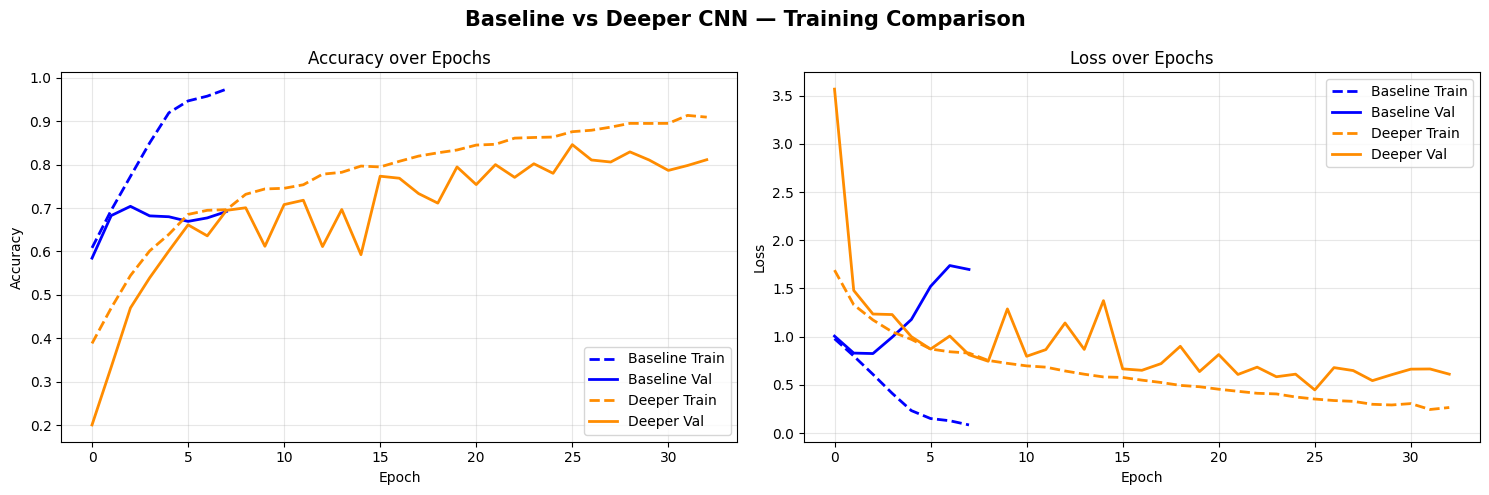

In [29]:
# ── COMPARE TRAINING CURVES ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Baseline vs Deeper CNN — Training Comparison', fontsize=15, fontweight='bold')

# Accuracy
axes[0].plot(baseline_history.history['accuracy'],     label='Baseline Train', color='blue',      linewidth=2, linestyle='--')
axes[0].plot(baseline_history.history['val_accuracy'], label='Baseline Val',   color='blue',      linewidth=2)
axes[0].plot(deeper_history.history['accuracy'],       label='Deeper Train',   color='darkorange', linewidth=2, linestyle='--')
axes[0].plot(deeper_history.history['val_accuracy'],   label='Deeper Val',     color='darkorange', linewidth=2)
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(baseline_history.history['loss'],     label='Baseline Train', color='blue',      linewidth=2, linestyle='--')
axes[1].plot(baseline_history.history['val_loss'], label='Baseline Val',   color='blue',      linewidth=2)
axes[1].plot(deeper_history.history['loss'],       label='Deeper Train',   color='darkorange', linewidth=2, linestyle='--')
axes[1].plot(deeper_history.history['val_loss'],   label='Deeper Val',     color='darkorange', linewidth=2)
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# ── EVALUATE DEEPER MODEL ───────────────────────────────────
val_gen.reset()
y_pred_probs_deep = deeper_model.predict(val_gen, verbose=1)
y_pred_deep = np.argmax(y_pred_probs_deep, axis=1)
y_true_deep = val_gen.classes

print("=" * 55)
print("     DEEPER MODEL — EVALUATION REPORT")
print("=" * 55)
print(classification_report(y_true_deep, y_pred_deep, target_names=class_names))

val_loss_deep, val_acc_deep = deeper_model.evaluate(val_gen, verbose=0)
print(f"Validation Accuracy : {val_acc_deep*100:.2f}%")
print(f"Validation Loss     : {val_loss_deep:.4f}")
print(f"Training Time       : {deeper_train_time/60:.2f} minutes")

47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step
     DEEPER MODEL — EVALUATION REPORT
              precision    recall  f1-score   support

       daisy       0.87      0.94      0.90       300
   dandelion       0.92      0.79      0.85       300
        rose       0.80      0.77      0.78       300
   sunflower       0.83      0.94      0.88       300
       tulip       0.82      0.80      0.81       300

    accuracy                           0.85      1500
   macro avg       0.85      0.85      0.84      1500
weighted avg       0.85      0.85      0.84      1500

Validation Accuracy : 84.60%
Validation Loss     : 0.4486
Training Time       : 20.05 minutes


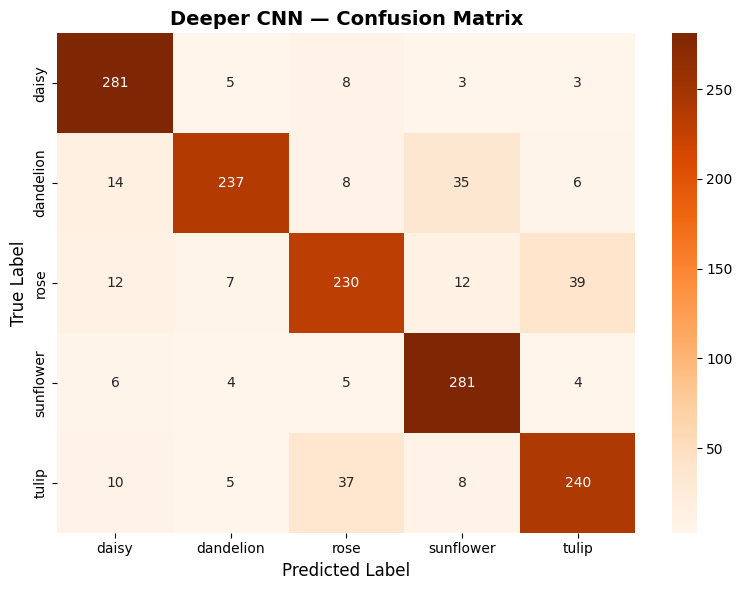

In [31]:
# ── CONFUSION MATRIX — DEEPER MODEL ─────────────────────────
cm_deep = confusion_matrix(y_true_deep, y_pred_deep)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Deeper CNN — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('deeper_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

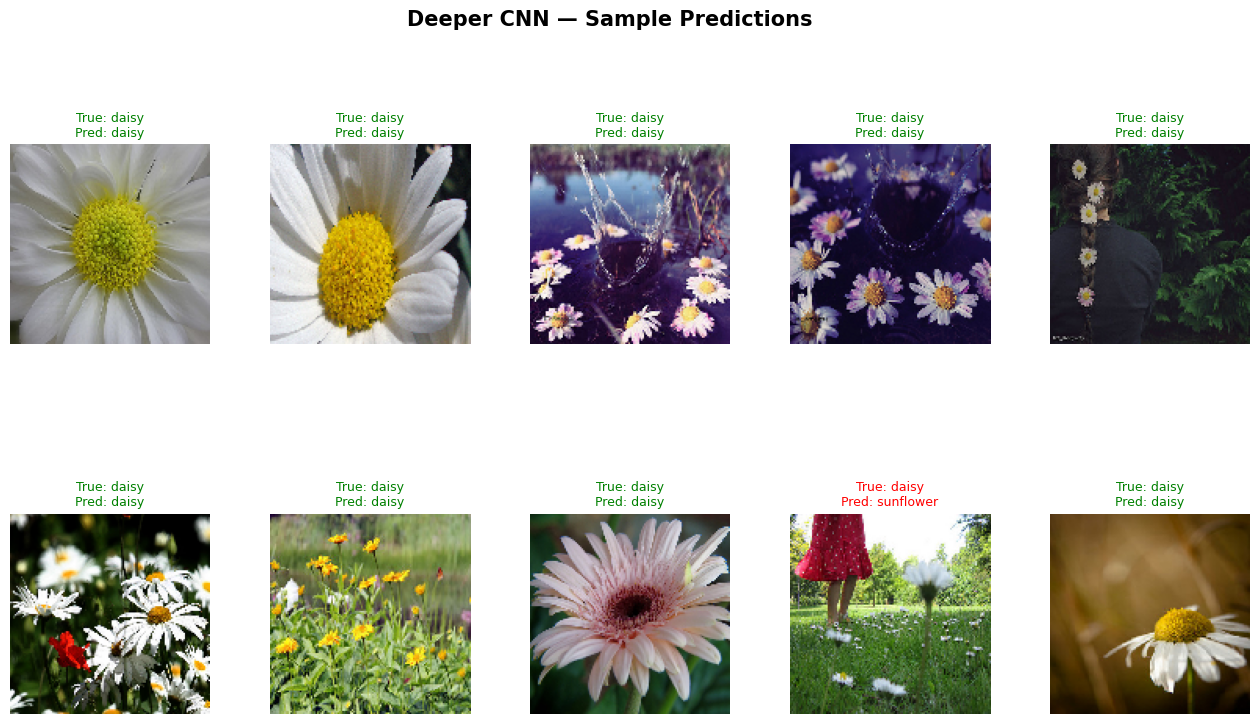

In [32]:
# ── SAMPLE PREDICTIONS — DEEPER MODEL ───────────────────────
val_gen.reset()
images, labels = next(val_gen)

fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle('Deeper CNN — Sample Predictions', fontsize=15, fontweight='bold', y=1.02)

for i, ax in enumerate(axes.flat):
    img  = images[i]
    true = class_names[int(labels[i])]
    pred = class_names[np.argmax(deeper_model.predict(img[np.newaxis,...], verbose=0))]
    color = 'green' if true == pred else 'red'
    ax.imshow(img)
    ax.set_title(f'True: {true}\nPred: {pred}', color=color, fontsize=9, pad=6)
    ax.axis('off')

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

In [33]:
# ── SGD vs ADAM EXPERIMENT (Lighter Version) ─────────────────

def build_deeper_model():
    model = keras.Sequential([
        keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

# ── Train with SGD ───────────────────────────────────────────
model_sgd = build_deeper_model()
model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training with SGD...\n")
start_sgd = time.time()

history_sgd = model_sgd.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True, verbose=1)],
    verbose=1
)

sgd_train_time = time.time() - start_sgd
val_loss_sgd, val_acc_sgd = model_sgd.evaluate(val_gen, verbose=0)
print(f"\nSGD — Val Accuracy: {val_acc_sgd*100:.2f}% | Val Loss: {val_loss_sgd:.4f} | Time: {sgd_train_time/60:.2f} min")

# ── Train with Adam ──────────────────────────────────────────
model_adam = build_deeper_model()
model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining with Adam...\n")
start_adam = time.time()

history_adam = model_adam.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True, verbose=1)],
    verbose=1
)

adam_train_time = time.time() - start_adam
val_loss_adam, val_acc_adam = model_adam.evaluate(val_gen, verbose=0)
print(f"\nAdam — Val Accuracy: {val_acc_adam*100:.2f}% | Val Loss: {val_loss_adam:.4f} | Time: {adam_train_time/60:.2f} min")

Training with SGD...

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 55s 227ms/step - accuracy: 0.3658 - loss: 1.6028 - val_accuracy: 0.3907 - val_loss: 1.4529
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 32s 172ms/step - accuracy: 0.4842 - loss: 1.2640 - val_accuracy: 0.4827 - val_loss: 1.1921
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 40s 169ms/step - accuracy: 0.5257 - loss: 1.1854 - val_accuracy: 0.5487 - val_loss: 1.1311
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 32s 169ms/step - accuracy: 0.5327 - loss: 1.1409 - val_accuracy: 0.5680 - val_loss: 1.0346
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 33s 175ms/step - accuracy: 0.5673 - loss: 1.0708 - val_accuracy: 0.6140 - val_loss: 0.9675
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 32s 167ms/step - accuracy: 0.5875 - loss: 1.0394 - val_accuracy: 0.5980 - val_loss: 0.9389
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 32s 170ms/step - accuracy: 0.6188 - loss: 0.9800 - val_accuracy: 0.6613 - val_loss: 0.8439
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 32s 170ms/step - accu

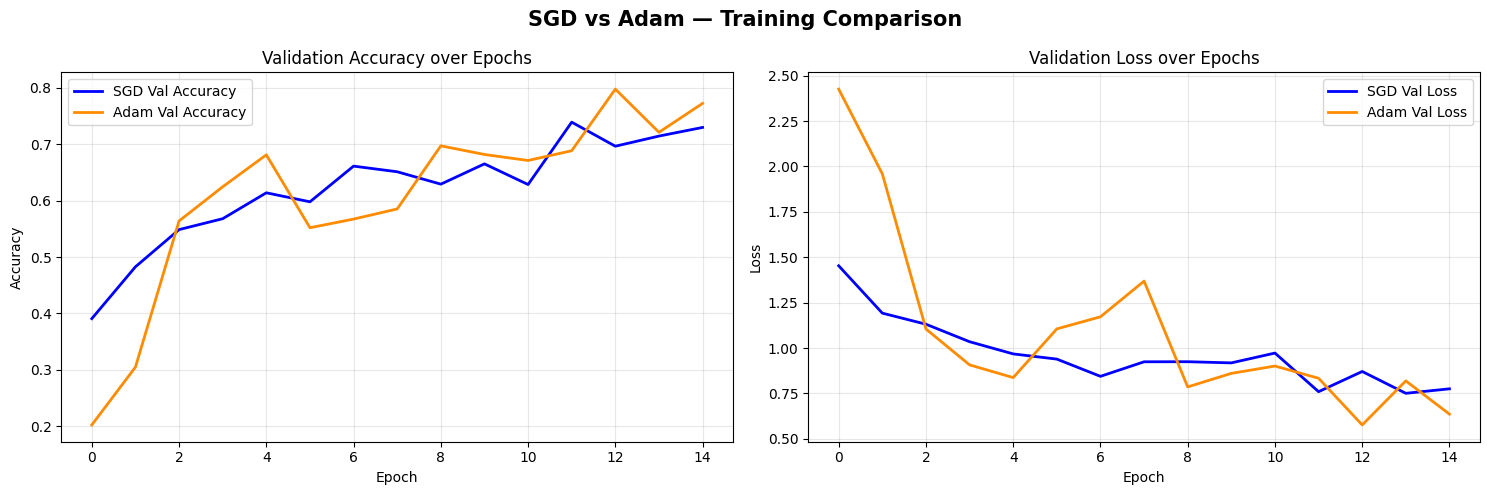

In [34]:
# ── SGD vs Adam — Comparison Plot ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('SGD vs Adam — Training Comparison', fontsize=15, fontweight='bold')

axes[0].plot(history_sgd.history['val_accuracy'],  label='SGD Val Accuracy',  color='blue',   linewidth=2)
axes[0].plot(history_adam.history['val_accuracy'], label='Adam Val Accuracy', color='darkorange', linewidth=2)
axes[0].set_title('Validation Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_sgd.history['val_loss'],  label='SGD Val Loss',  color='blue',   linewidth=2)
axes[1].plot(history_adam.history['val_loss'], label='Adam Val Loss', color='darkorange', linewidth=2)
axes[1].set_title('Validation Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# ── SGD Evaluation ──────────────────────────────────────────
val_gen.reset()
y_pred_sgd = np.argmax(model_sgd.predict(val_gen, verbose=0), axis=1)
print("SGD — Classification Report")
print(classification_report(val_gen.classes, y_pred_sgd, target_names=class_names))

# ── Adam Evaluation ─────────────────────────────────────────
val_gen.reset()
y_pred_adam = np.argmax(model_adam.predict(val_gen, verbose=0), axis=1)
print("Adam — Classification Report")
print(classification_report(val_gen.classes, y_pred_adam, target_names=class_names))

SGD — Classification Report
              precision    recall  f1-score   support

       daisy       0.94      0.63      0.75       300
   dandelion       0.67      0.86      0.76       300
        rose       0.57      0.70      0.63       300
   sunflower       0.80      0.86      0.83       300
       tulip       0.71      0.53      0.60       300

    accuracy                           0.71      1500
   macro avg       0.74      0.71      0.71      1500
weighted avg       0.74      0.71      0.71      1500

Adam — Classification Report
              precision    recall  f1-score   support

       daisy       0.82      0.85      0.84       300
   dandelion       0.82      0.76      0.79       300
        rose       0.69      0.79      0.74       300
   sunflower       0.85      0.89      0.87       300
       tulip       0.83      0.70      0.76       300

    accuracy                           0.80      1500
   macro avg       0.80      0.80      0.80      1500
weighted avg       0

In [36]:
# ── ABLATION STUDY — REMOVE DROPOUT ─────────────────────────

def build_ablation_model():
    model = keras.Sequential([
        keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        # Conv Block 1 — No Dropout
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Conv Block 2 — No Dropout
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Conv Block 3 — No Dropout
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Conv Block 4 — No Dropout
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.GlobalAveragePooling2D(),

        # FCN — No Dropout
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),

        layers.Dense(128, activation='relu'),

        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name="Ablation_No_Dropout")

    return model

# ── Build & Compile ──────────────────────────────────────────
model_ablation = build_ablation_model()
model_ablation.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_ablation.summary()

# ── Train ────────────────────────────────────────────────────
print("\nTraining Ablation Model (No Dropout)...\n")
start_ablation = time.time()

history_ablation = model_ablation.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True, verbose=1)],
    verbose=1
)

ablation_train_time = time.time() - start_ablation

# ── Evaluate ─────────────────────────────────────────────────
val_gen.reset()
y_pred_ablation = np.argmax(model_ablation.predict(val_gen, verbose=0), axis=1)

val_loss_abl, val_acc_abl = model_ablation.evaluate(val_gen, verbose=0)

print("=" * 55)
print("   ABLATION MODEL (No Dropout) — EVALUATION REPORT")
print("=" * 55)
print(classification_report(val_gen.classes, y_pred_ablation, target_names=class_names))
print(f"Validation Accuracy : {val_acc_abl*100:.2f}%")
print(f"Validation Loss     : {val_loss_abl:.4f}")
print(f"Training Time       : {ablation_train_time/60:.2f} minutes")

Model: "Ablation_No_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 256)            │         1,02

 Total params: 685,349 (2.61 MB)

 Trainable params: 683,429 (2.61 MB)

 Non-trainable params: 1,920 (7.50 KB)


Training Ablation Model (No Dropout)...

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 51s 213ms/step - accuracy: 0.5213 - loss: 1.1855 - val_accuracy: 0.2413 - val_loss: 1.9037
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 32s 168ms/step - accuracy: 0.6168 - loss: 0.9821 - val_accuracy: 0.4873 - val_loss: 1.3380
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 32s 169ms/step - accuracy: 0.6787 - loss: 0.8512 - val_accuracy: 0.5567 - val_loss: 1.2080
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 32s 172ms/step - accuracy: 0.6998 - loss: 0.7908 - val_accuracy: 0.6553 - val_loss: 0.9636
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 42s 176ms/step - accuracy: 0.7335 - loss: 0.7107 - val_accuracy: 0.6507 - val_loss: 0.9848
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 34s 178ms/step - accuracy: 0.7597 - loss: 0.6526 - val_accuracy: 0.6987 - val_loss: 0.8850
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 33s 175ms/step - accuracy: 0.7798 - loss: 0.5967 - val_accuracy: 0.7413 - val_loss: 0.7255
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 3

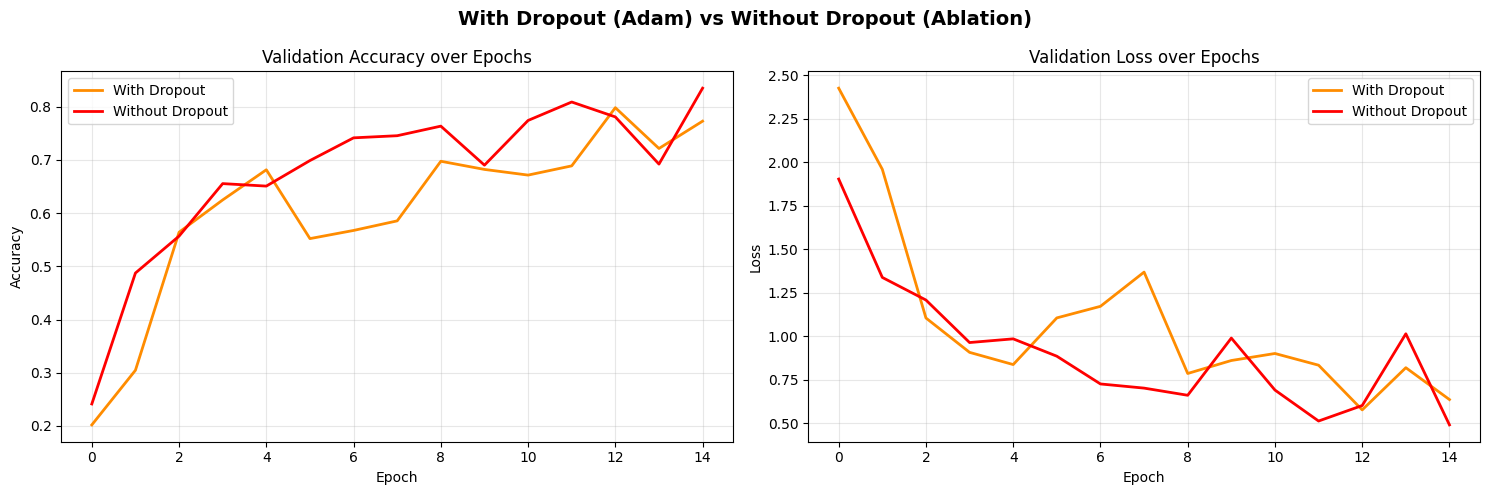

In [37]:
# ── ABLATION vs ADAM — Comparison Plot ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('With Dropout (Adam) vs Without Dropout (Ablation)',
             fontsize=14, fontweight='bold')

axes[0].plot(history_adam.history['val_accuracy'],
             label='With Dropout', color='darkorange', linewidth=2)
axes[0].plot(history_ablation.history['val_accuracy'],
             label='Without Dropout', color='red', linewidth=2)
axes[0].set_title('Validation Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_adam.history['val_loss'],
             label='With Dropout', color='darkorange', linewidth=2)
axes[1].plot(history_ablation.history['val_loss'],
             label='Without Dropout', color='red', linewidth=2)
axes[1].set_title('Validation Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Transfer Learning

In [38]:
# ── PART B: TRANSFER LEARNING — MobileNetV2 (Fixed) ─────────
from tensorflow.keras.applications import MobileNetV2

# ── New generators WITHOUT rescaling (MobileNetV2 handles it) ─
transfer_train_gen = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

transfer_val_gen = ImageDataGenerator(
    validation_split=0.2
)

train_gen_tl = transfer_train_gen.flow_from_directory(
    augmented_train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    seed=42,
    shuffle=True
)

val_gen_tl = transfer_val_gen.flow_from_directory(
    augmented_train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    seed=42,
    shuffle=False
)

print("Class indices:", train_gen_tl.class_indices)
print(f"Training samples  : {train_gen_tl.samples}")
print(f"Validation samples: {val_gen_tl.samples}")

Found 6000 images belonging to 5 classes.
Found 1500 images belonging to 5 classes.
Class indices: {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
Training samples  : 6000
Validation samples: 1500


In [39]:
# ── Load Pre-trained Base ────────────────────────────────────
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

print(f"Base model layers   : {len(base_model.layers)}")
print(f"Trainable variables : {len(base_model.trainable_variables)}")

# ── Build Full Model ─────────────────────────────────────────
inputs  = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Rescale [0,255] → MobileNetV2 expected range [-1, 1]
x = layers.Rescaling(scale=1./127.5, offset=-1)(inputs)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model = keras.Model(inputs, outputs, name='MobileNetV2_Transfer')

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers   : 154
Trainable variables : 0


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,485 (10.00 MB)

 Trainable params: 361,989 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [40]:
# ── PHASE 1: Feature Extraction ──────────────────────────────
print("Phase 1: Feature Extraction (Frozen Base)...\n")

start_transfer = time.time()

history_phase1 = transfer_model.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=10,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4,
                             restore_best_weights=True, verbose=1)],
    verbose=1
)

phase1_time = time.time() - start_transfer
val_loss_p1, val_acc_p1 = transfer_model.evaluate(val_gen_tl, verbose=0)
print(f"\nPhase 1 — Val Accuracy: {val_acc_p1*100:.2f}% | Val Loss: {val_loss_p1:.4f} | Time: {phase1_time/60:.2f} min")

Phase 1: Feature Extraction (Frozen Base)...

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 110s 472ms/step - accuracy: 0.7093 - loss: 0.8512 - val_accuracy: 0.8100 - val_loss: 0.5224
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 58s 307ms/step - accuracy: 0.7902 - loss: 0.5764 - val_accuracy: 0.8467 - val_loss: 0.4226
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 58s 307ms/step - accuracy: 0.8190 - loss: 0.5083 - val_accuracy: 0.8440 - val_loss: 0.4347
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 58s 308ms/step - accuracy: 0.8307 - loss: 0.4833 - val_accuracy: 0.8353 - val_loss: 0.4412
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 58s 307ms/step - accuracy: 0.8373 - loss: 0.4374 - val_accuracy: 0.8393 - val_loss: 0.4658
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 58s 308ms/step - accuracy: 0.8352 - loss: 0.4340 - val_accuracy: 0.8427 - val_loss: 0.4332
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.

Phase 1 — Val Accuracy: 84.67% | Val Loss: 0.4226 | Time: 6.79 min


In [41]:
# ── PHASE 2: Fine-Tuning ─────────────────────────────────────
print("Phase 2: Fine-Tuning (Unfreezing top 30 layers)...\n")

base_model.trainable = True

# Freeze all except last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Total layers in base  : {len(base_model.layers)}")
print(f"Trainable layers now  : {sum(1 for l in base_model.layers if l.trainable)}")

# Lower learning rate for fine-tuning
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_finetune = time.time()

history_phase2 = transfer_model.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=10,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4,
                             restore_best_weights=True, verbose=1)],
    verbose=1
)

finetune_time = time.time() - start_finetune
total_transfer_time = phase1_time + finetune_time
print(f"\nPhase 2 complete | Time: {finetune_time/60:.2f} min")

Phase 2: Fine-Tuning (Unfreezing top 30 layers)...

Total layers in base  : 154
Trainable layers now  : 30
Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 94s 403ms/step - accuracy: 0.7568 - loss: 0.6605 - val_accuracy: 0.8407 - val_loss: 0.4573
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 62s 330ms/step - accuracy: 0.7770 - loss: 0.6156 - val_accuracy: 0.8440 - val_loss: 0.4524
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 58s 307ms/step - accuracy: 0.7975 - loss: 0.5584 - val_accuracy: 0.8460 - val_loss: 0.4425
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 57s 304ms/step - accuracy: 0.8157 - loss: 0.5152 - val_accuracy: 0.8480 - val_loss: 0.4230
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 57s 305ms/step - accuracy: 0.8170 - loss: 0.4889 - val_accuracy: 0.8573 - val_loss: 0.4081
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 57s 305ms/step - accuracy: 0.8255 - loss: 0.4790 - val_accuracy: 0.8593 - val_loss: 0.3996
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 57s 306ms/step - accuracy: 0.8298 - loss: 0.4741 - val_accuracy: 0.

In [42]:
# ── EVALUATE ─────────────────────────────────────────────────
val_gen_tl.reset()
y_pred_transfer = np.argmax(transfer_model.predict(val_gen_tl, verbose=1), axis=1)

val_loss_tl, val_acc_tl = transfer_model.evaluate(val_gen_tl, verbose=0)

print("=" * 55)
print("   TRANSFER LEARNING MODEL — EVALUATION REPORT")
print("=" * 55)
print(classification_report(val_gen_tl.classes, y_pred_transfer, target_names=class_names))
print(f"Validation Accuracy : {val_acc_tl*100:.2f}%")
print(f"Validation Loss     : {val_loss_tl:.4f}")
print(f"Phase 1 Time        : {phase1_time/60:.2f} minutes")
print(f"Phase 2 Time        : {finetune_time/60:.2f} minutes")
print(f"Total Training Time : {total_transfer_time/60:.2f} minutes")

47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 257ms/step
   TRANSFER LEARNING MODEL — EVALUATION REPORT
              precision    recall  f1-score   support

       daisy       0.93      0.89      0.91       300
   dandelion       0.84      0.93      0.88       300
        rose       0.88      0.82      0.85       300
   sunflower       0.90      0.88      0.89       300
       tulip       0.80      0.84      0.82       300

    accuracy                           0.87      1500
   macro avg       0.87      0.87      0.87      1500
weighted avg       0.87      0.87      0.87      1500

Validation Accuracy : 87.00%
Validation Loss     : 0.3700
Phase 1 Time        : 6.79 minutes
Phase 2 Time        : 10.30 minutes
Total Training Time : 17.09 minutes


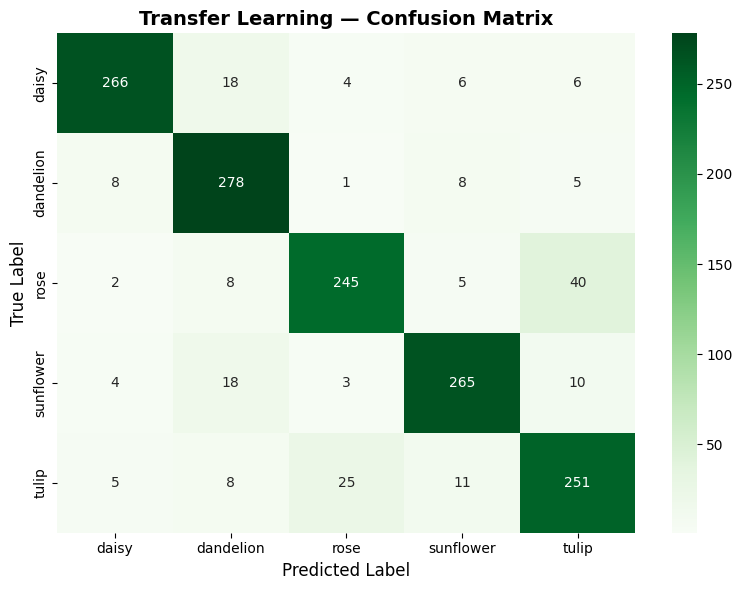

In [43]:
# ── CONFUSION MATRIX ─────────────────────────────────────────
cm_tl = confusion_matrix(val_gen_tl.classes, y_pred_transfer)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Transfer Learning — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

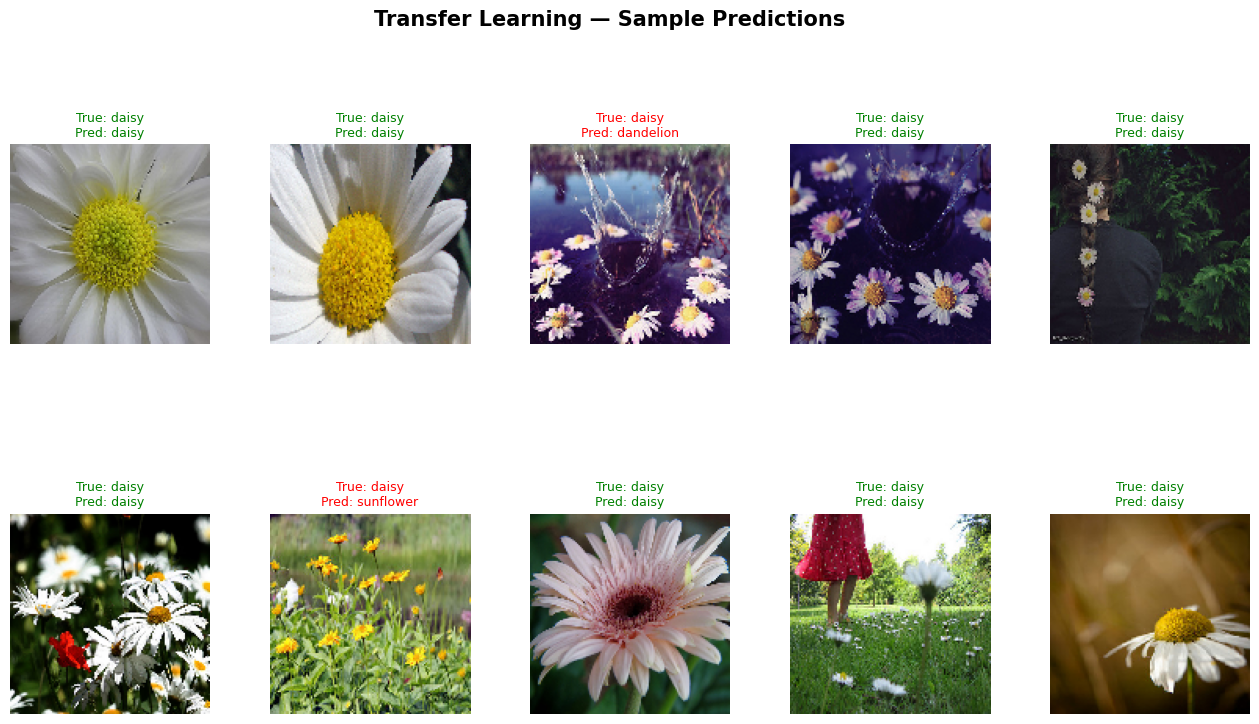

In [44]:
# ── SAMPLE PREDICTIONS ───────────────────────────────────────
val_gen_tl.reset()
images, labels = next(val_gen_tl)

fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle('Transfer Learning — Sample Predictions', fontsize=15, fontweight='bold', y=1.02)

for i, ax in enumerate(axes.flat):
    img  = images[i]
    true = class_names[int(labels[i])]
    pred = class_names[np.argmax(transfer_model.predict(img[np.newaxis,...], verbose=0))]
    color = 'green' if true == pred else 'red'
    ax.imshow((img).astype('uint8'))
    ax.set_title(f'True: {true}\nPred: {pred}', color=color, fontsize=9, pad=6)
    ax.axis('off')

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

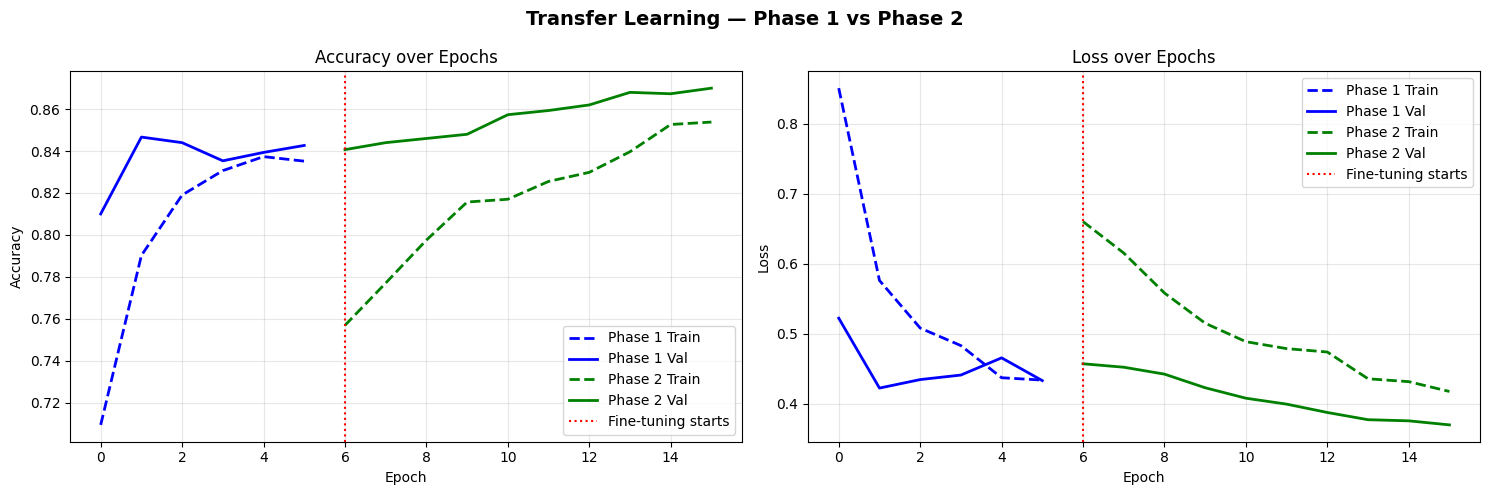

In [45]:
# ── TRAINING CURVES ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Transfer Learning — Phase 1 vs Phase 2', fontsize=14, fontweight='bold')

p1_epochs = len(history_phase1.history['accuracy'])
p2_epochs = len(history_phase2.history['accuracy'])
p2_x = range(p1_epochs, p1_epochs + p2_epochs)

axes[0].plot(history_phase1.history['accuracy'],
             label='Phase 1 Train', color='blue', linewidth=2, linestyle='--')
axes[0].plot(history_phase1.history['val_accuracy'],
             label='Phase 1 Val', color='blue', linewidth=2)
axes[0].plot(p2_x, history_phase2.history['accuracy'],
             label='Phase 2 Train', color='green', linewidth=2, linestyle='--')
axes[0].plot(p2_x, history_phase2.history['val_accuracy'],
             label='Phase 2 Val', color='green', linewidth=2)
axes[0].axvline(x=p1_epochs, color='red', linestyle=':', linewidth=1.5, label='Fine-tuning starts')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_phase1.history['loss'],
             label='Phase 1 Train', color='blue', linewidth=2, linestyle='--')
axes[1].plot(history_phase1.history['val_loss'],
             label='Phase 1 Val', color='blue', linewidth=2)
axes[1].plot(p2_x, history_phase2.history['loss'],
             label='Phase 2 Train', color='green', linewidth=2, linestyle='--')
axes[1].plot(p2_x, history_phase2.history['val_loss'],
             label='Phase 2 Val', color='green', linewidth=2)
axes[1].axvline(x=p1_epochs, color='red', linestyle=':', linewidth=1.5, label='Fine-tuning starts')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()